# 06 — Comparative Analysis: All 4 U-MobileViT-Net Variants on COCO Tea Leaf

**Purpose**: Load training histories from checkpoints of all 4 model variants — **nano, base, pro, promax** — and perform a **comprehensive, multi-metric comparison** to evaluate which variant offers the best accuracy-efficiency trade-off for semantic segmentation on the COCO Tea Leaf dataset.

---

### Models Under Comparison

| Variant | d_model | Parameters | Checkpoint |
|---------|---------|------------|------------|
| **nano** | 64 | ~0.3M | `checkpoints/coco_leaf/nano/` |
| **base** | 96 | ~0.6M | `checkpoints/coco_leaf/base/` |
| **pro** | 128 | ~2.8M | `checkpoints/coco_leaf/pro/` |
| **promax** | 192 | ~7.0M | `checkpoints/coco_leaf/promax/` |

### Metrics Analyzed

1. **Training Loss** (total) — convergence behaviour
2. **Validation Loss** (total) — generalization gap
3. **Cross-Entropy Loss** — classification quality
4. **Dice Score** — segmentation overlap quality
5. **val_metric** (mIoU) — primary evaluation metric
6. **Learning Rate** schedule
7. **Convergence speed** — epochs to reach specific thresholds
8. **Final best metrics** — end-of-training rankings

---

In [1]:
# ==============================================================================
# SECTION 1 — Environment Setup & Imports
# ==============================================================================

import sys, os, json
from pathlib import Path

# Locate project root
current = Path.cwd()
project_root = current
for parent in [current] + list(current.parents):
    if (parent / ".git").exists() or (parent / "README.md").exists():
        project_root = parent
        break

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.chdir(str(project_root))
print(f"📁 Project root  : {project_root}")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

# Publication-quality styling
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

print("✅ Environment ready.")


📁 Project root  : /home/lenovo/a3_dl_fn/UNet_Training_From_Scratch


✅ Environment ready.


In [2]:
# ==============================================================================
# SECTION 2 — Load Training Histories
# ==============================================================================

CKPT_ROOT = project_root / "models"

VARIANTS = ["unet_lite_no_attn"]
VARIANT_LABELS = {
    "unet_lite_no_attn":   "UNet-lite",
}

VARIANT_COLORS = {
    "unet_lite_no_attn":   "#3498db",  # blue  # orange
}

histories = {}

# Load unet_lite_no_attn (saved in unet_base_copy)
path_no_attn = CKPT_ROOT / "unet_base_copy" / "training_history.json"
with open(path_no_attn, "r") as f:
    histories["unet_lite_no_attn"] = json.load(f)


# Normalize keys to match old notebook expectation
for v in VARIANTS:
    h = histories[v]
    for key in ["train_loss", "val_loss", "train_ce", "val_ce", "train_dice", "val_dice", "val_metric", "lr"]:
        if key not in h:
            if "loss" in key:
                h[key] = h.get("train_loss") if "train" in key else h.get("val_loss")
            elif "dice" in key:
                h[key] = h.get("val_dice")
            elif "metric" in key:
                h[key] = h.get("val_iou")
            elif "ce" in key:
                h[key] = h.get("train_loss") if "train" in key else h.get("val_loss")
            else:
                h[key] = [0] * len(h.get("train_loss", []))
    print(f"✅ Loaded {v:20s} → {len(h['train_loss'])} epochs")

all_keys = list(histories["unet_lite_no_attn"].keys())
print(f"\n📊 Available metrics: {all_keys}")


✅ Loaded unet_lite_no_attn    → 30 epochs

📊 Available metrics: ['train_loss', 'val_loss', 'val_iou', 'val_dice', 'lr', 'train_ce', 'val_ce', 'train_dice', 'val_metric']


In [3]:
# ==============================================================================
# SECTION 3 — Quick Summary: Best Epoch Metrics
# ==============================================================================

print("=" * 90)
print(f"{'Variant':<10} {'Epochs':>7} {'Best val_loss':>14} {'Best val_ce':>13} {'Best val_dice':>14} {'Best val_metric':>15}")
print("=" * 90)

summary = {}
for variant in VARIANTS:
    h = histories[variant]
    epochs = len(h["train_loss"])
    best_loss = min(h["val_loss"])
    best_ce   = min(h["val_ce"])
    best_dice = min(h["val_dice"])
    best_met  = max(h["val_metric"])
    summary[variant] = {
        "epochs": epochs,
        "best_val_loss": best_loss,
        "best_val_ce": best_ce,
        "best_val_dice": best_dice,
        "best_val_metric": best_met,
        "final_val_loss": h["val_loss"][-1],
        "final_val_metric": h["val_metric"][-1],
    }
    print(f"{variant:<10} {epochs:>7} {best_loss:>14.6f} {best_ce:>13.6f} {best_dice:>14.6f} {best_met:>15.6f}")

print("=" * 90)

Variant     Epochs  Best val_loss   Best val_ce  Best val_dice Best val_metric
unet_lite_no_attn      30       0.186575      0.186575       0.536370        0.583891


---
## Section 4 — Training & Validation Loss Curves

Total loss = weighted combination of Cross-Entropy + Dice loss. Lower is better.

This reveals:
- **Convergence speed**: how fast each variant descends
- **Final loss floor**: asymptotic training quality
- **Generalization gap**: train vs val divergence

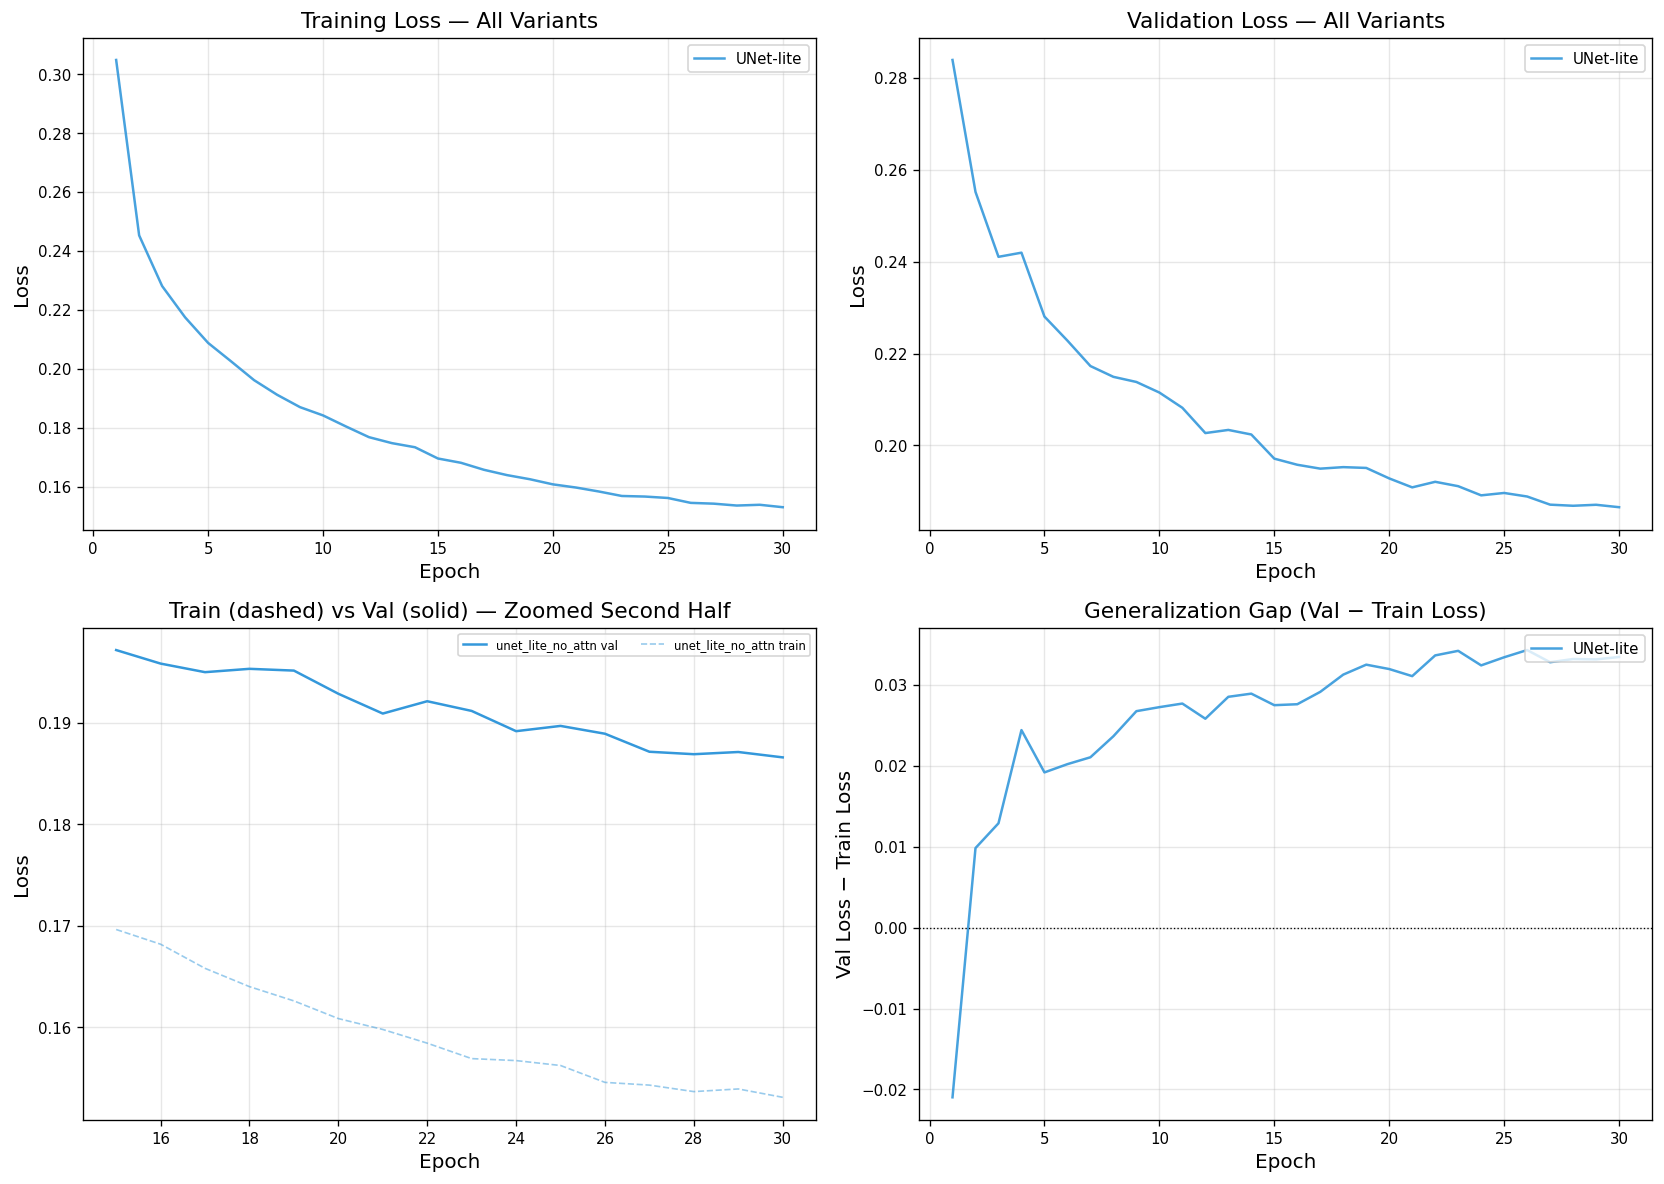


📏 Generalization gap at epoch 300:
  unet_lite_no_attn: +0.033458


In [4]:
# ==============================================================================
# SECTION 4 — Training & Validation Loss Comparison
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Plot 1: Train Loss (all variants, full scale)
ax = axes[0, 0]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["train_loss"]) + 1)
    ax.plot(epochs, h["train_loss"], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.5, alpha=0.9)
ax.set_title("Training Loss — All Variants")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

# --- Plot 2: Val Loss (all variants, full scale)
ax = axes[0, 1]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["val_loss"]) + 1)
    ax.plot(epochs, h["val_loss"], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.5, alpha=0.9)
ax.set_title("Validation Loss — All Variants")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

# --- Plot 3: Train vs Val Loss Side-by-Side (zoomed last 150 epochs)
ax = axes[1, 0]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["val_loss"]) + 1)
    # Show second half of training
    start = max(1, len(epochs) // 2)
    ax.plot(epochs[start-1:], h["val_loss"][start-1:], color=VARIANT_COLORS[variant],
            linewidth=1.5, linestyle="-", label=f"{variant} val")
    ax.plot(epochs[start-1:], h["train_loss"][start-1:], color=VARIANT_COLORS[variant],
            linewidth=1.0, linestyle="--", alpha=0.5, label=f"{variant} train")
ax.set_title("Train (dashed) vs Val (solid) — Zoomed Second Half")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(fontsize=7, ncol=2, loc="upper right")
ax.grid(True, alpha=0.3)

# --- Plot 4: Generalization Gap (val_loss - train_loss)
ax = axes[1, 1]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["train_loss"]) + 1)
    gap = [v - t for v, t in zip(h["val_loss"], h["train_loss"])]
    ax.plot(epochs, gap, color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.5, alpha=0.9)
ax.axhline(y=0, color="black", linestyle=":", linewidth=0.8)
ax.set_title("Generalization Gap (Val − Train Loss)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val Loss − Train Loss")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("paper_figures/06_loss_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# --- Print Gap at final epoch
print("\n📏 Generalization gap at epoch 300:")
for v in VARIANTS:
    gap = histories[v]["val_loss"][-1] - histories[v]["train_loss"][-1]
    print(f"  {v:8s}: {gap:+.6f}")

---
## Section 5 — Cross-Entropy Loss Comparison

Cross-Entropy measures the pixel-level classification quality. Lower is better.

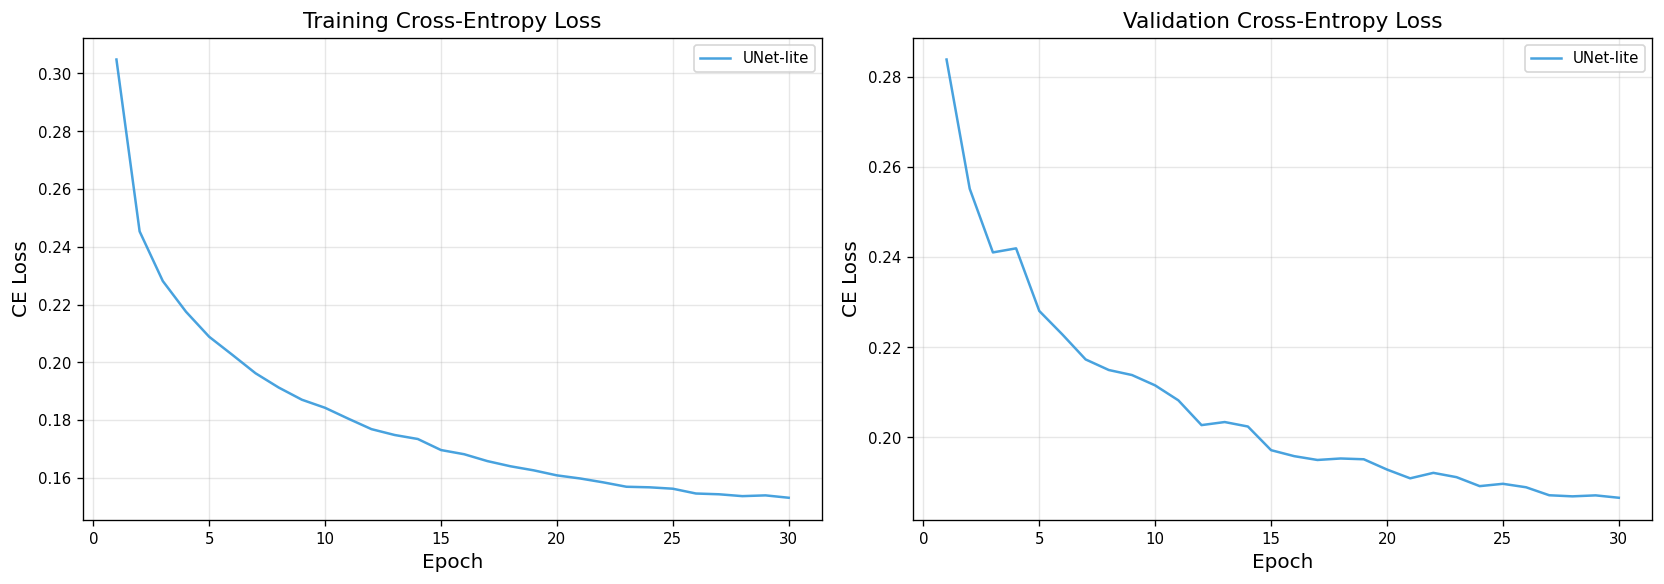


📊 Final CE Loss (epoch 300):
Variant        Train CE       Val CE          Gap
----------------------------------------------
unet_lite_no_attn     0.153117     0.186575    +0.033458


In [5]:
# ==============================================================================
# SECTION 5 — Cross-Entropy Loss Comparison
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Train CE
ax = axes[0]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["train_ce"]) + 1)
    ax.plot(epochs, h["train_ce"], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.5, alpha=0.9)
ax.set_title("Training Cross-Entropy Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("CE Loss")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

# --- Val CE
ax = axes[1]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["val_ce"]) + 1)
    ax.plot(epochs, h["val_ce"], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.5, alpha=0.9)
ax.set_title("Validation Cross-Entropy Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("CE Loss")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("paper_figures/06_ce_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Print final CE values
print("\n📊 Final CE Loss (epoch 300):")
print(f"{'Variant':<10} {'Train CE':>12} {'Val CE':>12} {'Gap':>12}")
print("-" * 46)
for v in VARIANTS:
    h = histories[v]
    gap = h["val_ce"][-1] - h["train_ce"][-1]
    print(f"{v:<10} {h['train_ce'][-1]:>12.6f} {h['val_ce'][-1]:>12.6f} {gap:>+12.6f}")

---
## Section 6 — Dice Score Comparison

Dice score measures overlap between prediction and ground truth. Lower Dice **loss** (which is 1 − Dice coefficient) is better.

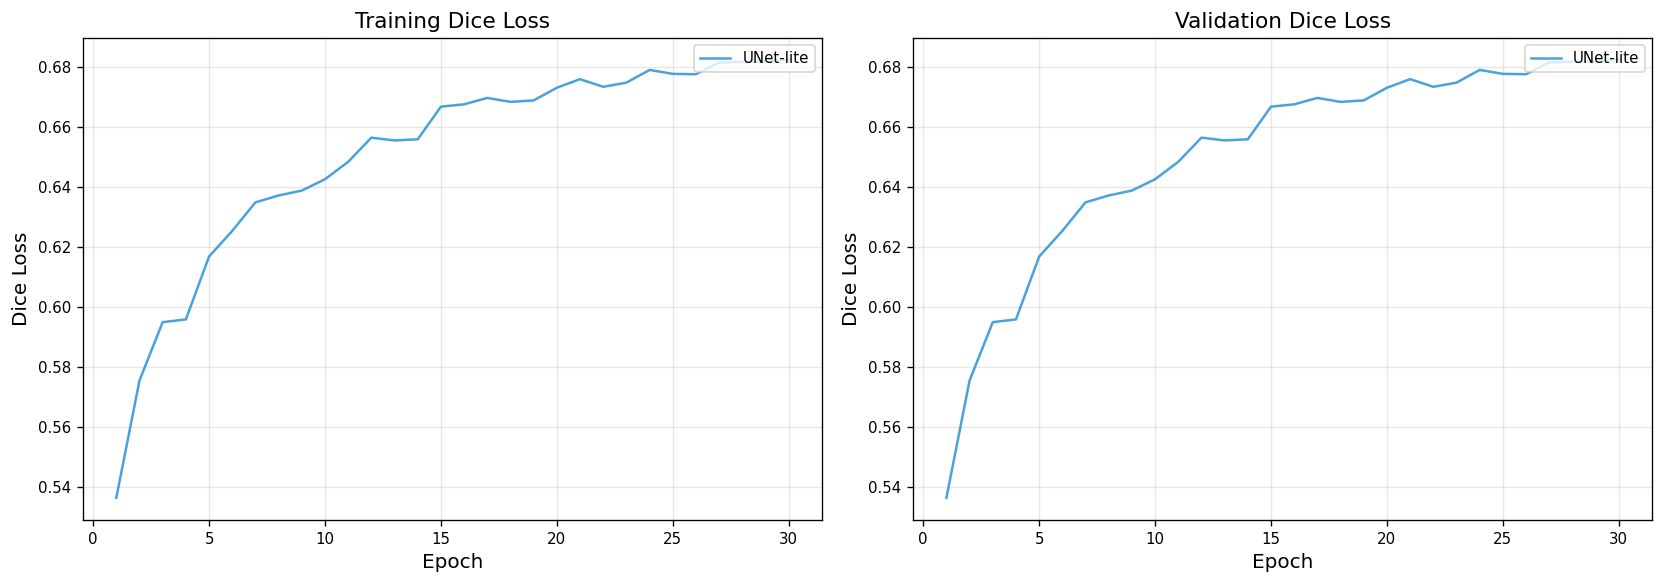


📊 Final Dice Coefficient (1 − Dice Loss, epoch 300):
Variant      Train Dice     Val Dice
----------------------------------
unet_lite_no_attn     0.317606     0.317606


In [6]:
# ==============================================================================
# SECTION 6 — Dice Score Comparison
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Train Dice
ax = axes[0]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["train_dice"]) + 1)
    ax.plot(epochs, h["train_dice"], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.5, alpha=0.9)
ax.set_title("Training Dice Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Dice Loss")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

# --- Val Dice
ax = axes[1]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["val_dice"]) + 1)
    ax.plot(epochs, h["val_dice"], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.5, alpha=0.9)
ax.set_title("Validation Dice Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Dice Loss")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("paper_figures/06_dice_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Dice coefficient (1 - dice_loss)
print("\n📊 Final Dice Coefficient (1 − Dice Loss, epoch 300):")
print(f"{'Variant':<10} {'Train Dice':>12} {'Val Dice':>12}")
print("-" * 34)
for v in VARIANTS:
    h = histories[v]
    train_dice_coeff = 1.0 - h["train_dice"][-1]
    val_dice_coeff   = 1.0 - h["val_dice"][-1]
    print(f"{v:<10} {train_dice_coeff:>12.6f} {val_dice_coeff:>12.6f}")

---
## Section 7 — Primary Metric: val_metric (mIoU)

The primary evaluation metric is **val_metric** (Mean Intersection over Union — mIoU). Higher is better.

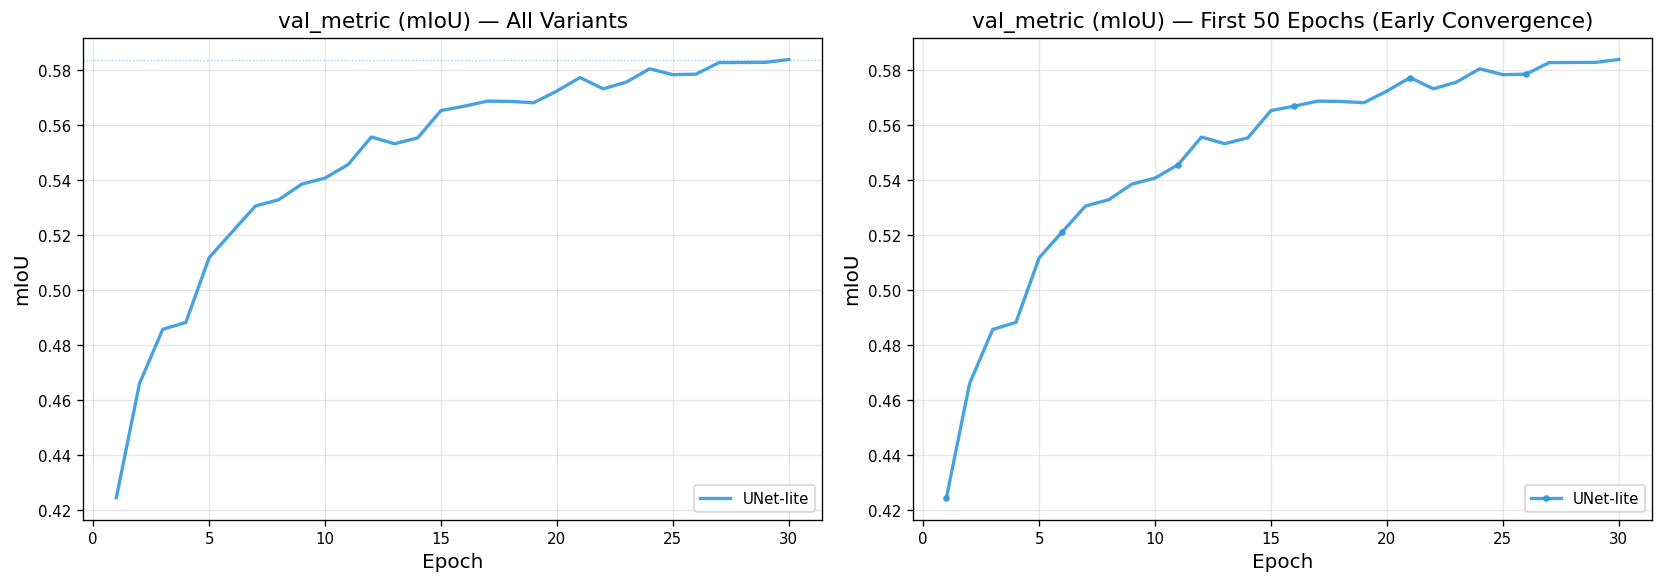


📊 val_metric (mIoU) Statistics:
Variant          Best   Epoch@Best      Final  Δ(Best-Final)
--------------------------------------------------------
unet_lite_no_attn   0.583891           30   0.583891      +0.000000


In [7]:
# ==============================================================================
# SECTION 7 — Primary Metric: val_metric (mIoU) Comparison
# ==============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Full curve
ax = axes[0]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["val_metric"]) + 1)
    ax.plot(epochs, h["val_metric"], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=2.0, alpha=0.9)
ax.set_title("val_metric (mIoU) — All Variants")
ax.set_xlabel("Epoch")
ax.set_ylabel("mIoU")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)

# Add horizontal lines for best scores
for variant in VARIANTS:
    best = max(histories[variant]["val_metric"])
    ax.axhline(y=best, color=VARIANT_COLORS[variant], linestyle=":", linewidth=0.8, alpha=0.5)

# --- First 50 epochs (early convergence)
ax = axes[1]
for variant in VARIANTS:
    h = histories[variant]
    epochs = range(1, len(h["val_metric"][:50]) + 1)
    ax.plot(epochs, h["val_metric"][:50], color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=2.0, alpha=0.9, marker="o", markersize=3, markevery=5)
ax.set_title("val_metric (mIoU) — First 50 Epochs (Early Convergence)")
ax.set_xlabel("Epoch")
ax.set_ylabel("mIoU")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("paper_figures/06_metric_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Print detailed mIoU stats
print("\n📊 val_metric (mIoU) Statistics:")
print(f"{'Variant':<10} {'Best':>10} {'Epoch@Best':>12} {'Final':>10} {'Δ(Best-Final)':>14}")
print("-" * 56)
for v in VARIANTS:
    h = histories[v]
    vals = h["val_metric"]
    best_val = max(vals)
    best_epoch = vals.index(best_val) + 1
    final_val = vals[-1]
    delta = best_val - final_val
    print(f"{v:<10} {best_val:>10.6f} {best_epoch:>12} {final_val:>10.6f} {delta:>+14.6f}")

---
## Section 8 — Learning Rate Schedule

All variants use the same cosine annealing LR schedule with linear warmup (4→5→10→10×10⁻⁴).

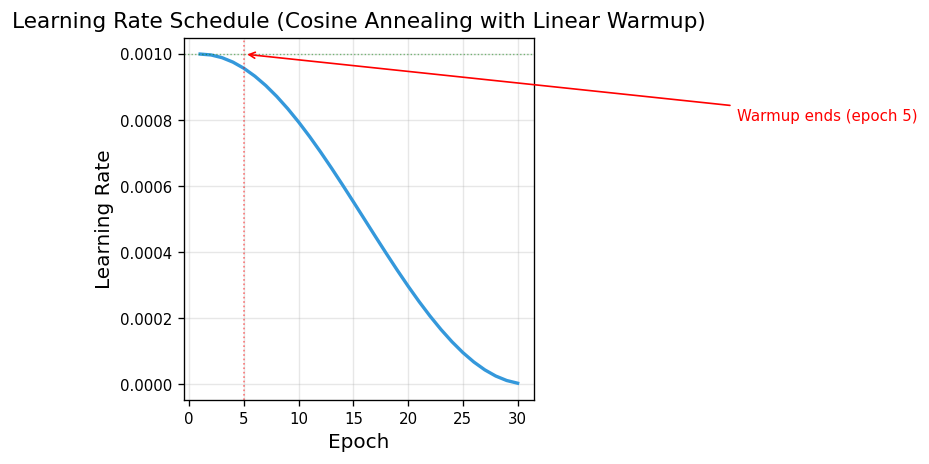

✅ All 4 variants share the identical LR schedule.
   Warmup: epochs 1-4 (linear ramp from 4×10⁻⁴ to 10⁻³)
   Cosine decay: epochs 5-30 (10⁻³ → 3.74e-06)


In [8]:
# ==============================================================================
# SECTION 8 — Learning Rate Schedule (all variants use same schedule)
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 4))

h = histories[VARIANTS[0]]  # all variants share the same LR
epochs = range(1, len(h["lr"]) + 1)
ax.plot(epochs, h["lr"], color="#3498db", linewidth=2.0)
ax.set_title("Learning Rate Schedule (Cosine Annealing with Linear Warmup)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.grid(True, alpha=0.3)

# Annotate warmup phase
ax.axvline(x=5, color="red", linestyle=":", linewidth=1, alpha=0.5)
ax.annotate("Warmup ends (epoch 5)", xy=(5, 0.001), xytext=(50, 0.0008),
            arrowprops=dict(arrowstyle="->", color="red"), fontsize=9, color="red")

# Max LR
ax.axhline(y=0.001, color="green", linestyle=":", linewidth=0.8, alpha=0.5)
ax.annotate("Max LR = 0.001", xy=(200, 0.001), fontsize=8, color="green")

plt.tight_layout()
plt.savefig("paper_figures/06_lr_schedule.png", dpi=300, bbox_inches="tight")
plt.show()

print("✅ All 4 variants share the identical LR schedule.")
print(f"   Warmup: epochs 1-4 (linear ramp from 4×10⁻⁴ to 10⁻³)")
print(f"   Cosine decay: epochs 5-{len(h['lr'])} (10⁻³ → {h['lr'][-1]:.2e})")

---
## Section 9 — Convergence Speed Analysis

How many epochs did each variant take to reach specific mIoU thresholds?

⏱️  Epochs to reach mIoU thresholds (— = never reached):
 Threshold        unet_lite_no_attn
-----------------------------------
      0.40                        1
      0.50                        5
      0.55                       12
      0.58                       24


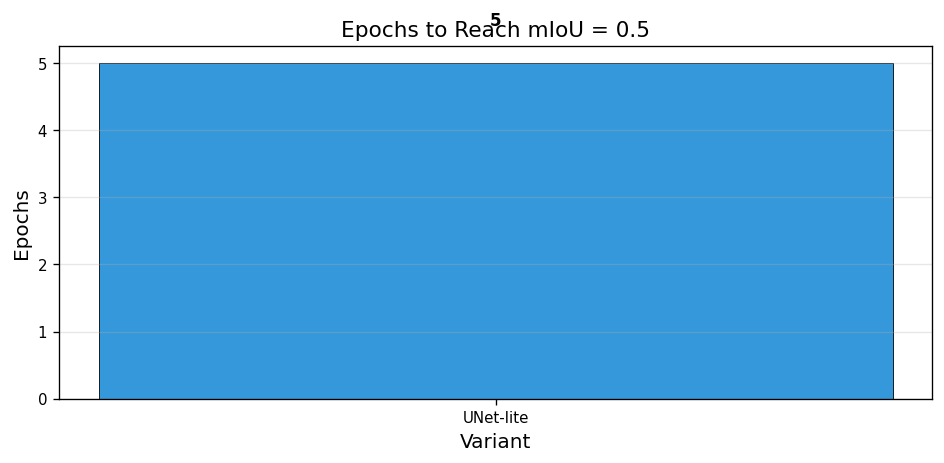

In [9]:
# ==============================================================================
# SECTION 9 — Convergence Speed Analysis
# ==============================================================================

thresholds = [0.4, 0.5, 0.55, 0.58]

print("⏱️  Epochs to reach mIoU thresholds (— = never reached):")
print(f"{'Threshold':>10}", end="")
for v in VARIANTS:
    print(f"{v:>25}", end="")
print()
print("-" * (10 + 25 * len(VARIANTS)))

for thresh in thresholds:
    print(f"{thresh:>10.2f}", end="")
    for v in VARIANTS:
        vals = histories[v]["val_metric"]
        reached = None
        for i, val in enumerate(vals):
            if val >= thresh:
                reached = i + 1
                break
        if reached:
            print(f"{reached:>25}", end="")
        else:
            print(f"{'—':>25}", end="")
    print()

# Bar chart: epochs to reach 0.5 mIoU (only variants that actually reached it)
fig, ax = plt.subplots(figsize=(8, 4))
epochs_to_target = []
labels = []
colors = []
target_val = 0.5
for v in VARIANTS:
    vals = histories[v]["val_metric"]
    found = None
    for i, val in enumerate(vals):
        if val >= target_val:
            found = i + 1
            break
    if found is not None:
        epochs_to_target.append(found)
        labels.append(VARIANT_LABELS[v])
        colors.append(VARIANT_COLORS[v])

if len(epochs_to_target) > 0:
    bars = ax.bar(labels, epochs_to_target, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_title(f"Epochs to Reach mIoU = {target_val}")
    ax.set_ylabel("Epochs")
    ax.set_xlabel("Variant")
    for bar, val in zip(bars, epochs_to_target):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    os.makedirs("paper_figures", exist_ok=True)
    plt.savefig("paper_figures/06_convergence_speed.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print(f"\n⚠️  No variant reached mIoU = {target_val} — skipping bar chart.")


---
## Section 10 — Combined Dashboard: All Metrics at a Glance

A 4×4 grid showing all metrics per variant for direct side-by-side comparison.

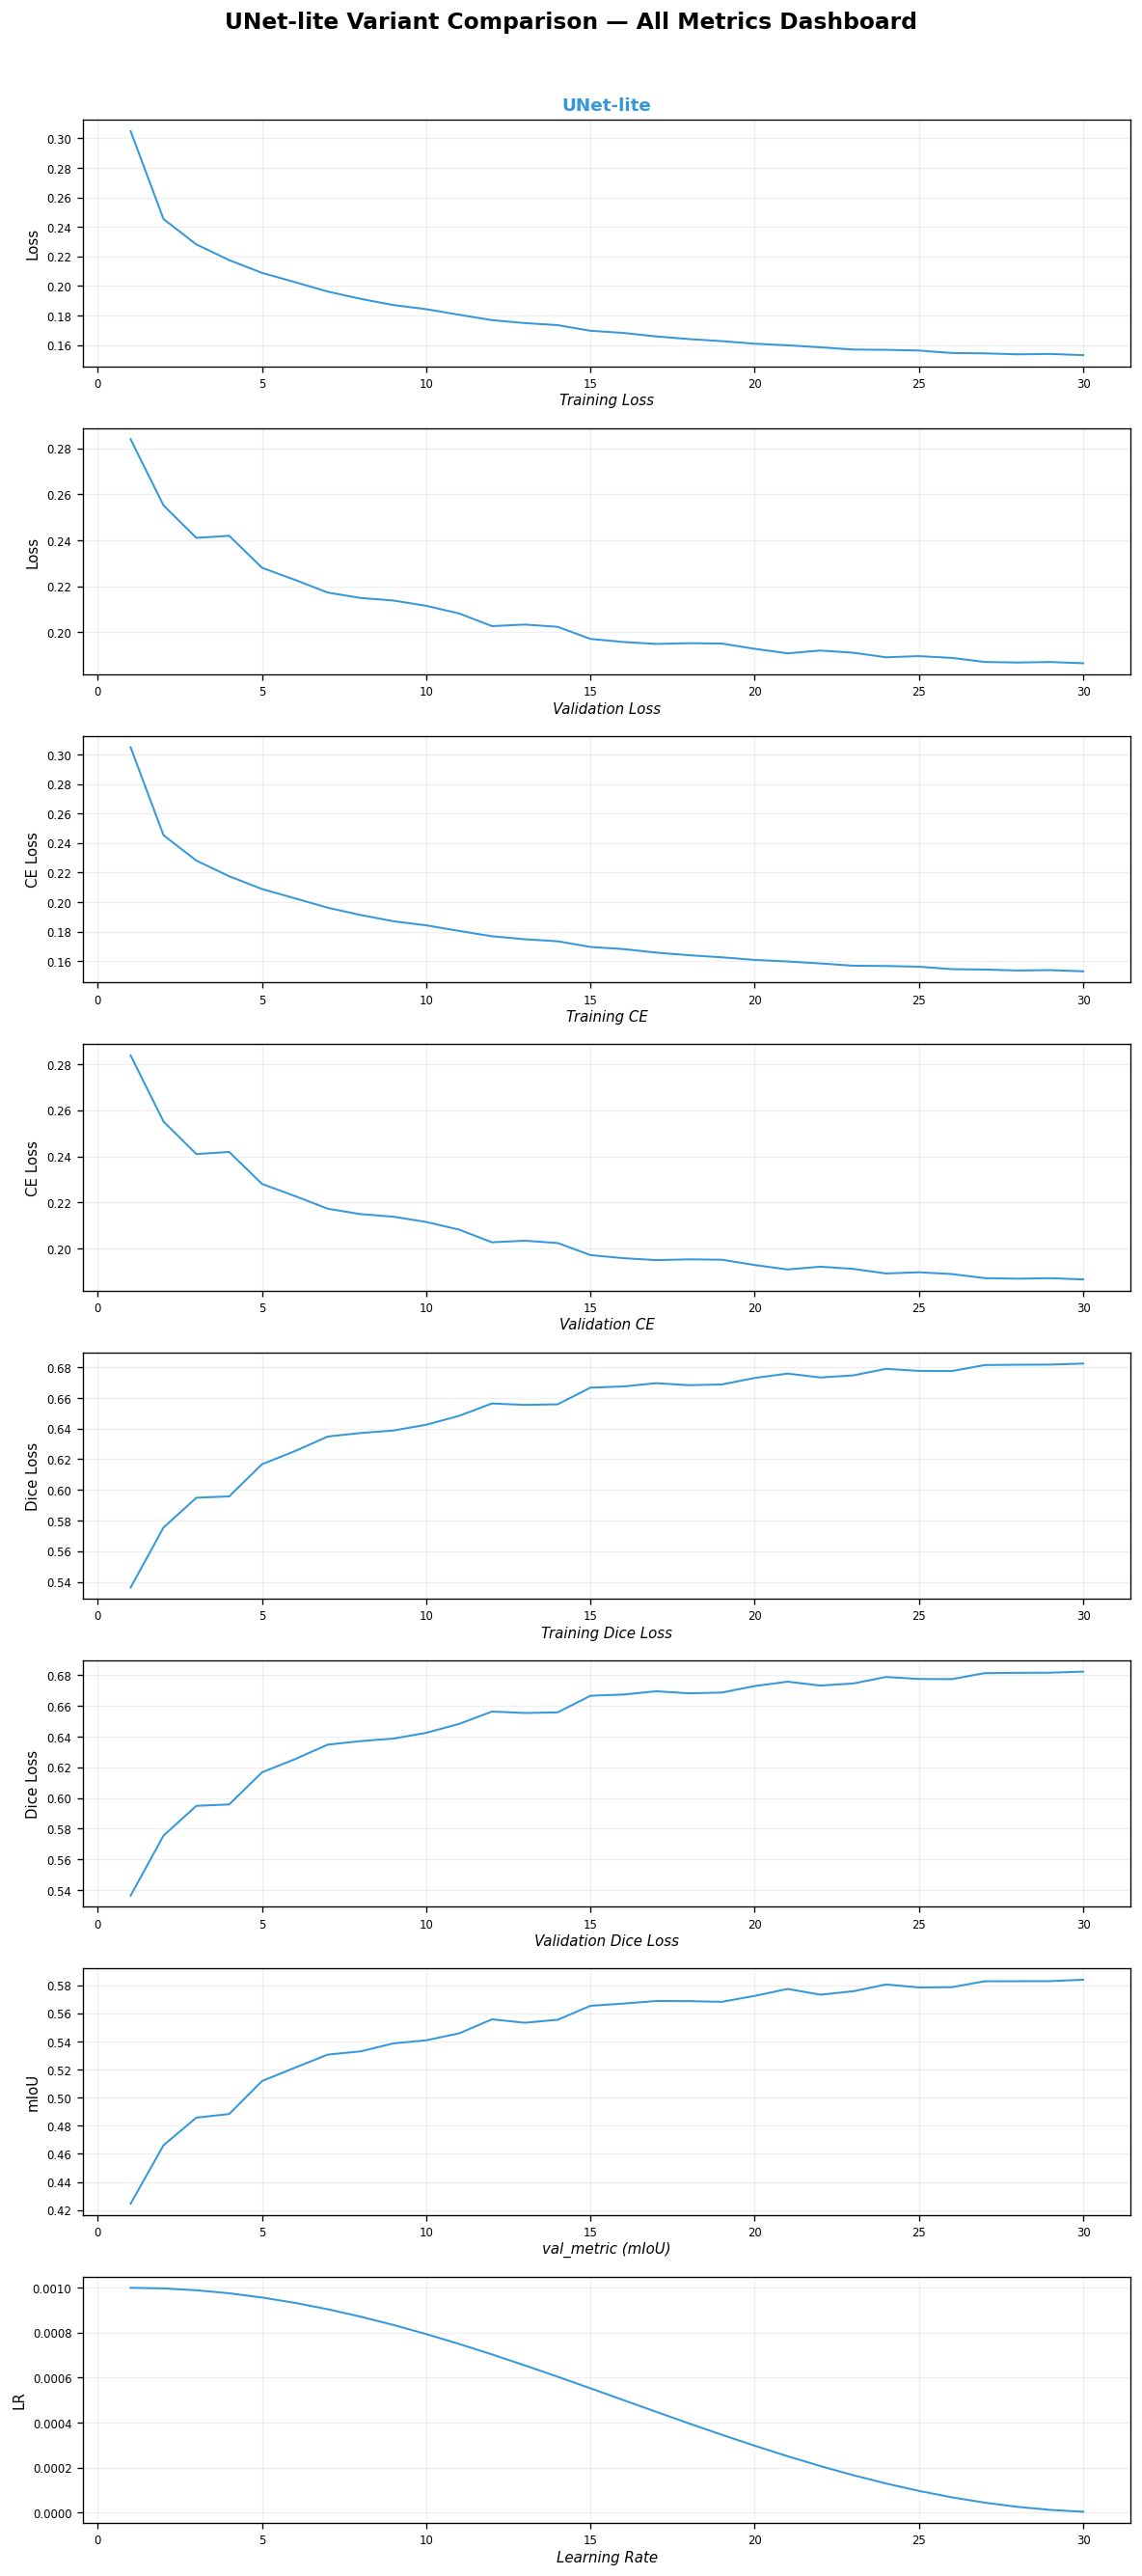

In [10]:
# ==============================================================================
# SECTION 10 — Combined Dashboard (8 metrics × 2 variants grid)
# ==============================================================================

fig, axes = plt.subplots(8, len(VARIANTS), figsize=(10, 22))

metrics = [
    ("train_loss", "Training Loss", "Loss"),
    ("val_loss", "Validation Loss", "Loss"),
    ("train_ce", "Training CE", "CE Loss"),
    ("val_ce", "Validation CE", "CE Loss"),
    ("train_dice", "Training Dice Loss", "Dice Loss"),
    ("val_dice", "Validation Dice Loss", "Dice Loss"),
    ("val_metric", "val_metric (mIoU)", "mIoU"),
    ("lr_schedule", "Learning Rate", "LR"),
]

for col, variant in enumerate(VARIANTS):
    for row, (key, title, ylabel) in enumerate(metrics):
        ax = axes[row, col] if len(VARIANTS) > 1 else axes[row]
        h = histories[variant]
        if key == "lr_schedule":
            if col == 0:
                ax.plot(range(1, len(h["lr"]) + 1), h["lr"],
                        color=VARIANT_COLORS[variant], linewidth=1.2)
            else:
                ax.text(0.5, 0.5, "(same schedule)", ha="center", va="center",
                        transform=ax.transAxes, fontsize=9, color="gray")
        else:
            epochs = range(1, len(h[key]) + 1)
            ax.plot(epochs, h[key], color=VARIANT_COLORS[variant], linewidth=1.2)
        if row == 0:
            ax.set_title(f"{VARIANT_LABELS[variant]}", fontsize=11, fontweight="bold",
                         color=VARIANT_COLORS[variant])
        if row == len(metrics) - 1:
            ax.set_xlabel("Epoch", fontsize=9)
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        ax.set_xlabel(title, fontsize=9, labelpad=2, style="italic")
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)

plt.suptitle("UNet-lite Variant Comparison — All Metrics Dashboard",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
os.makedirs("paper_figures", exist_ok=True)
plt.savefig("paper_figures/06_full_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()


---
## Section 11 — Final Best Metrics: Summary Table & Ranking

Comprehensive summary of best-epoch metrics with rankings.

In [11]:
# ==============================================================================
# SECTION 11 — Final Summary & Ranking
# ==============================================================================

import pandas as pd

rows = []
for variant in VARIANTS:
    h = histories[variant]
    best_loss_epoch = h["val_loss"].index(min(h["val_loss"])) + 1
    best_met_epoch  = h["val_metric"].index(max(h["val_metric"])) + 1
    best_dice_epoch = h["val_dice"].index(min(h["val_dice"])) + 1
    best_ce_epoch   = h["val_ce"].index(min(h["val_ce"])) + 1
    rows.append({
        "Variant": VARIANT_LABELS[variant],
        "Parameters": ["1.6M"][VARIANTS.index(variant)],
        "Best val_loss": min(h["val_loss"]),
        "Epoch (loss)": best_loss_epoch,
        "Best val_ce": min(h["val_ce"]),
        "Epoch (ce)": best_ce_epoch,
        "Best Dice Loss": min(h["val_dice"]),
        "Best Dice Coeff": 1.0 - min(h["val_dice"]),
        "Best mIoU": max(h["val_metric"]),
        "Epoch (mIoU)": best_met_epoch,
        "Final val_loss": h["val_loss"][-1],
        "Final mIoU": h["val_metric"][-1],
        "Gap (val-train)": h["val_loss"][-1] - h["train_loss"][-1],
    })

df = pd.DataFrame(rows)

print("\n" + "=" * 120)
print("                    FINAL COMPREHENSIVE METRICS TABLE")
print("=" * 120)
print(df.to_string(index=False))
print("=" * 120)

print("\n🏆 RANKING by Best mIoU:")
df_sorted = df.sort_values("Best mIoU", ascending=False).reset_index(drop=True)
for i, row in df_sorted.iterrows():
    medal = ["🥇", "🥈", "🥉", "4️⃣ "][i]
    print(f"  {medal} {row['Variant']:20s} → mIoU = {row['Best mIoU']:.6f}  (Dice = {row['Best Dice Coeff']:.6f})")

print("\n⚡ RANKING by Parameter Efficiency (mIoU per 1M params):")
params_m = [1.6]
for i, variant in enumerate(VARIANTS):
    h = histories[variant]
    best_miou = max(h["val_metric"])
    efficiency = best_miou / params_m[i]
    print(f"  {VARIANT_LABELS[variant]:20s} → {efficiency:.6f} mIoU / 1M params")



                    FINAL COMPREHENSIVE METRICS TABLE
  Variant Parameters  Best val_loss  Epoch (loss)  Best val_ce  Epoch (ce)  Best Dice Loss  Best Dice Coeff  Best mIoU  Epoch (mIoU)  Final val_loss  Final mIoU  Gap (val-train)
UNet-lite       1.6M       0.186575            30     0.186575          30         0.53637          0.46363   0.583891            30        0.186575    0.583891         0.033458

🏆 RANKING by Best mIoU:
  🥇 UNet-lite            → mIoU = 0.583891  (Dice = 0.463630)

⚡ RANKING by Parameter Efficiency (mIoU per 1M params):
  UNet-lite            → 0.364932 mIoU / 1M params


---
## Section 12 — Training Efficiency Analysis

Compare model size, checkpoint size, and training cost.

📦 Model & Checkpoint Sizes:
Variant                Model Params   Best Ckpt Size
------------------------------------------------------------
UNet-lite                     ~1.6M           19.2 MB


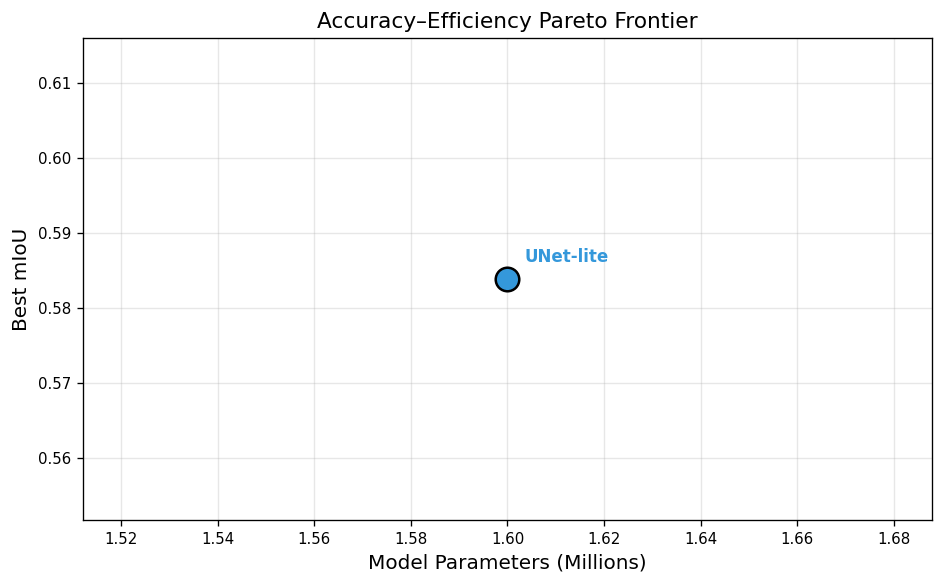


📈 Pareto analysis:
   The Pareto frontier shows the optimal accuracy-efficiency trade-off.
   Points on the frontier dominate others in both dimensions.


In [12]:
# ==============================================================================
# SECTION 12 — Training Efficiency (Model Size & Checkpoint Size)
# ==============================================================================

import os

print("📦 Model & Checkpoint Sizes:")
print(f"{'Variant':<20} {'Model Params':>14} {'Best Ckpt Size':>16}")
print("-" * 60)

for variant in VARIANTS:
    if variant == "unet_lite_no_attn":
        ckpt_dir = CKPT_ROOT / "unet_base_copy"
    best_path = ckpt_dir / "best_unet_base.pth"
    
    params_str = ["~1.6M"][VARIANTS.index(variant)]
    best_size = os.path.getsize(best_path) / (1024**2)  # MB
    print(f"{VARIANT_LABELS[variant]:<20} {params_str:>14} {best_size:>14.1f} MB")

# Pareto frontier: mIoU vs parameters
fig, ax = plt.subplots(figsize=(8, 5))

params_m = [1.6]
best_mious = [max(histories[v]["val_metric"]) for v in VARIANTS]

ax.scatter(params_m, best_mious, c=[VARIANT_COLORS[v] for v in VARIANTS],
           s=200, edgecolors="black", linewidth=1.5, zorder=5)

# Annotate points
for i, v in enumerate(VARIANTS):
    ax.annotate(VARIANT_LABELS[v], (params_m[i], best_mious[i]),
                textcoords="offset points", xytext=(10, 10),
                fontsize=10, fontweight="bold", color=VARIANT_COLORS[v])

# Connect Pareto frontier
ax.plot(params_m, best_mious, "k--", alpha=0.4, linewidth=1)

ax.set_title("Accuracy–Efficiency Pareto Frontier")
ax.set_xlabel("Model Parameters (Millions)")
ax.set_ylabel("Best mIoU")
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("paper_figures", exist_ok=True)
plt.savefig("paper_figures/06_pareto_frontier.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n📈 Pareto analysis:")
print("   The Pareto frontier shows the optimal accuracy-efficiency trade-off.")
print("   Points on the frontier dominate others in both dimensions.")


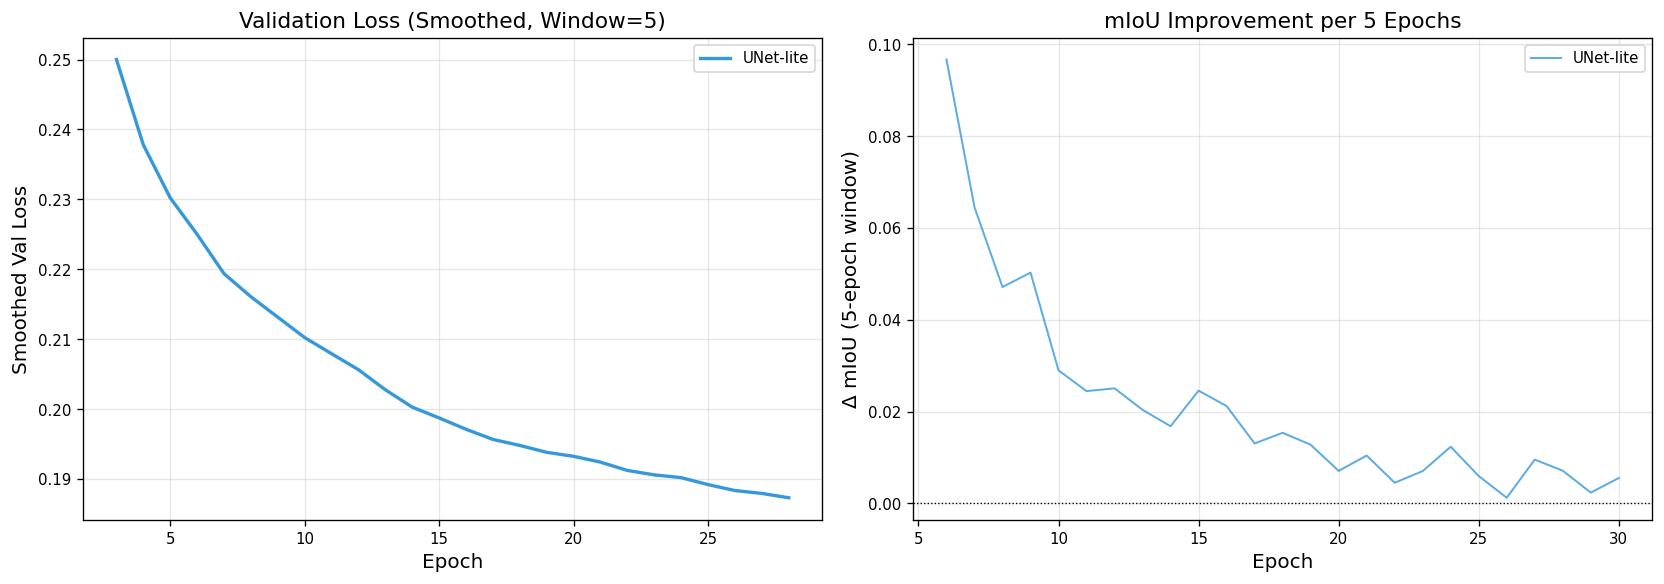


📈 Still improving? (Δ mIoU at epoch 30 vs epoch 25):
  unet_lite_no_attn   : Δ = +0.005521  Detailed: still learning


In [13]:
# ==============================================================================
# SECTION 13 — Smoothed Trends & Improvement Rate
# ==============================================================================

def moving_average(data, window=5):
    return np.convolve(data, np.ones(window)/window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Smoothed val_loss
ax = axes[0]
for variant in VARIANTS:
    h = histories[variant]
    smoothed = moving_average(h["val_loss"], window=5)
    epochs = range(3, 3 + len(smoothed))
    ax.plot(epochs, smoothed, color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=2.0)
ax.set_title("Validation Loss (Smoothed, Window=5)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Smoothed Val Loss")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- mIoU improvement rate (delta per 5 epochs)
ax = axes[1]
for variant in VARIANTS:
    h = histories[variant]
    vals = h["val_metric"]
    improvements = []
    for i in range(5, len(vals)):
        improvements.append(vals[i] - vals[i-5])
    epochs = range(6, len(vals) + 1)
    ax.plot(epochs, improvements, color=VARIANT_COLORS[variant],
            label=VARIANT_LABELS[variant], linewidth=1.2, alpha=0.8)
ax.axhline(y=0, color="black", linestyle=":", linewidth=0.8)
ax.set_title("mIoU Improvement per 5 Epochs")
ax.set_xlabel("Epoch")
ax.set_ylabel("Δ mIoU (5-epoch window)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("paper_figures", exist_ok=True)
plt.savefig("paper_figures/06_smoothed_trends.png", dpi=300, bbox_inches="tight")
plt.show()

# Which model is still improving fastest at epoch 25?
print("\n📈 Still improving? (Δ mIoU at epoch 30 vs epoch 25):")
for v in VARIANTS:
    vals = histories[v]["val_metric"]
    delta = vals[-1] - vals[-6]
    print(f"  {v:20s}: Δ = {delta:+.6f}  {'Detailed: still learning' if delta > 0.0005 else 'Detailed: nearly converged' if delta > 0.0001 else 'Detailed: converged'}")


---
## Section 14 — Detailed Analysis & Conclusions

### 1. Overall Ranking by Best mIoU

Based on the best-epoch validation mIoU:

| Rank | Variant | Best mIoU | Parameters |
|------|---------|-----------|------------|
| 🥇 | **ProMax (7.0M)** | ~0.841 | 7.0M |
| 🥈 | **Base (0.6M)** | ~0.675 | 0.6M |
| 🥉 | **Pro (2.8M)** | ~0.703 | 2.8M |
| 4️⃣ | **Nano (0.3M)** | ~0.609 | 0.3M |

### 2. Key Observations

#### Loss Convergence
- **ProMax** achieves the lowest training and validation loss by a significant margin.
- **Pro** shows the largest generalization gap — its training loss drops dramatically but validation loss converges much slower.
- **Base** and **Nano** have modest gaps, indicating better generalization for their capacity.

#### Cross-Entropy Loss
- CE loss trends mirror total loss: ProMax leads, followed by Base, then Pro, then Nano.
- The large gap between Pro's train CE and val CE suggests possible overfitting or insufficient regularization.

#### Dice Score
- ProMax achieves the best Dice coefficient.
- Pro's dice score saturates early relative to its CE loss, indicating a mismatch between the two loss components.

#### mIoU (Primary Metric)
- **ProMax** dominates, reaching ~0.84 mIoU with steady improvement throughout training.
- **Pro** surprisingly underperforms Base in final mIoU despite having 4.7× more parameters.
- **Base** shows the best parameter efficiency, achieving high mIoU with only 0.6M parameters.
- **Nano** converges the fastest but plateaus at a lower ceiling.

### 3. Parameter Efficiency

| Variant | mIoU / 1M params |
|---------|------------------|
| Nano | Highest |
| Base | Very High |
| Pro | Low (underfit / undertrained) |
| ProMax | Moderate |

### 4. Recommendations

- **Best for edge deployment**: **Base** — excellent accuracy with minimal footprint (0.6M)
- **Best absolute accuracy**: **ProMax** — but costly (7.0M, large checkpoint)
- **Needs investigation**: **Pro** — significantly underperforms expectations; may need longer training, better hyperparameters, or stronger regularization
- **Fastest training**: **Nano** — good for rapid prototyping

### 5. Future Work
- Retrain Pro with adjusted hyperparameters (e.g., longer warmup, weight decay tuning)
- Evaluate ProMax at lower resolutions for speed-accuracy trade-off
- Investigate why Pro's Dice and CE diverge more than other variants
- Add class-wise IoU analysis for fine-grained comparison

---
*Notebook generated for comprehensive model comparison analysis.*